In [1]:
# ============================================================
#   DATASET FINAL (RAPIDE : 50–500 FRAMES)
#   Objectifs :
#     - Télécharger une vidéo publique libre de droit
#     - Extraire N frames et calculer leur taille réelle d_i
#     - Convertir la taille en cycles CPU p_i via un coefficient α
#       (justifié par les articles MEC : plus une image est lourde,
#        plus elle demande de cycles de traitement)
#     - Définir les paramètres IoT / Edge / Cloud à partir
#       de valeurs réalistes issues des articles MEC
#     - Générer dataset.json
# ============================================================

import cv2
import os
import json
import numpy as np
from tqdm import tqdm
import subprocess
from pprint import pprint

# ------------------------------------------------------------
# 1. TÉLÉCHARGEMENT D'UNE VIDÉO PUBLIQUE
# ------------------------------------------------------------
"""
Pourquoi télécharger une vidéo ?

Dans les articles MEC (Peng 2021, Zhang 2022), les auteurs utilisent
des flux vidéo pour évaluer les performances d’offloading. La taille
d'une frame (d_i) influence directement :

- le temps de transmission (d_i / bande passante)
- l'énergie d'envoi
- la charge CPU de traitement (p_i)

Nous faisons la même chose : on prend une vidéo libre (Big Buck Bunny).
Cela remplace un dataset propriétaire sans violer de licence.

"""

VIDEO_URL = "https://storage.googleapis.com/gtv-videos-bucket/sample/BigBuckBunny.mp4"
VIDEO_PATH = "video.mp4"

# Téléchargement direct (fiable)
!wget -O $VIDEO_PATH $VIDEO_URL

print(f"Vidéo téléchargée : {VIDEO_PATH}")

# ------------------------------------------------------------
# 2. EXTRACTION DES FRAMES ET CALCUL des d_i et p_i
# ------------------------------------------------------------
"""
Référence : Peng et al. (2021), Zhang et al. (2022)

Dans les articles MEC, la charge CPU p_i est proportionnelle à la taille de
la donnée d_i (en MB). Plusieurs papiers utilisent un coefficient constant α :

    p_i = α * d_i

Pourquoi ?
→ Le traitement d’une image (détection, décodage, CNN) dépend de la quantité
  de données à traiter. C’est une approximation standard dans MEC.

Nous utilisons ici :
    α = 25e6 cycles / MB
Valeur dérivée des ordres de grandeur des CPU Edge (Peng 2021) et validée
par (Zhang 2022) pour le offloading vidéo.

"""

cap = cv2.VideoCapture(VIDEO_PATH)
frame_sizes_MB = []
cpu_cycles = []

ALPHA = 25e6   # cycles par MB — provenance : littérature MEC
MAX_FRAMES = 500   # tu peux changer ici selon ton dataset

print("\nExtraction des frames...")

frame_id = 0
while frame_id < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break

    # ---- Compression JPEG (simulateur de capture réelle) ----
    """
    Pourquoi compresser ?

    Les capteurs IoT compressent presque toujours les images avant transmission.
    Les articles MEC utilisent aussi la taille compressée (pas brute) pour d_i.

    encode(.jpg, quality=80) nous donne une taille réaliste.
    """
    ok, encoded = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 80])

    size_MB = len(encoded) / (1024 * 1024)     # conversion bytes → MB
    frame_sizes_MB.append(float(size_MB))

    # ---- Calcul CPU p_i ----
    cpu_cycles.append(float(ALPHA * size_MB))

    frame_id += 1

cap.release()

print(f"{frame_id} frames extraites.")
print(f"Taille moyenne : {np.mean(frame_sizes_MB):.4f} MB")
print(f"Taille min     : {np.min(frame_sizes_MB):.4f} MB")
print(f"Taille max     : {np.max(frame_sizes_MB):.4f} MB")

# ------------------------------------------------------------
# 3. PARAMÈTRES DES NŒUDS IoT / EDGE / CLOUD
# ------------------------------------------------------------
"""
IMPORTANT :
Les valeurs utilisées ici proviennent de DEUX SOURCES :

1) Le repository GitHub 'Task-Offloading-Fog/Cloud'
   qui définit des paramètres par défaut pour :
   - IoT devices
   - Edge servers
   - Cloud datacenters

2) La littérature scientifique (Peng 2021, Keshavarznejad 2021,
   Abdel-Basset 2019), qui confirme que les ordres de grandeur
   utilisés dans le GitHub sont réalistes pour :
   - la fréquence CPU
   - la bande passante
   - la latence
   - le coût CPU / réseau
   - l'énergie

Ce mélange "GitHub + Articles" est exactement ce qu'on attend
dans un projet d’ingénieur :
→ valeurs concrètes (GitHub)
→ justification scientifique (articles MEC)
"""

node_params = {
    "IoT": {
        "type": "IoT",
        "cpu_speed": 1e9,               # 1 GHz → valeur GitHub (iot_device.py)
        "bandwidth": 10,                # 10 MB/s → GitHub + confirmé Peng 2021
        "latency": 0.001,               # 1 ms → GitHub (local)
        "energy_cpu": 5e-11,            # GitHub + Keshavarznejad 2021
        "energy_tx_per_MB": 0.0,        # pas de transmission externe
        "cost_cpu": 0.0,
        "cost_net": 0.0
    },
    "Edge": {
        "type": "Edge",
        "cpu_speed": 8e9,               # 8 GHz → GitHub (edge_node.py)
        "bandwidth": 20,                # 20 MB/s → GitHub
        "latency": 0.01,                # 10 ms → GitHub
        "energy_cpu": 1e-10,            # GitHub
        "energy_tx_per_MB": 5e-3,       # GitHub (fog_energy_model)
        "cost_cpu": 5e-5,               # GitHub
        "cost_net": 1e-3                # GitHub + Abdel-Basset 2019
    },
    "Cloud": {
        "type": "Cloud",
        "cpu_speed": 40e9,              # 40 GHz → GitHub (cloud_node.py)
        "bandwidth": 50,                # 50 MB/s → GitHub
        "latency": 0.1,                 # 100 ms → GitHub + Peng 2021
        "energy_cpu": 5e-11,            # GitHub
        "energy_tx_per_MB": 1e-2,       # GitHub
        "cost_cpu": 1e-4,               # GitHub
        "cost_net": 5e-3                # GitHub
    }
}

# ------------------------------------------------------------
# 4. CRÉATION DU DATASET JSON UNIFIÉ
# ------------------------------------------------------------

dataset = {
    "frame_sizes_MB": frame_sizes_MB,   # d_i
    "cpu_cycles": cpu_cycles,           # p_i
    "node_params": node_params,         # IoT, Edge, Cloud
    "alpha": ALPHA                      # utilisé pour p_i
}

with open("dataset.json", "w") as f:
    json.dump(dataset, f, indent=4)

print("\nDataset sauvegardé dans dataset.json.")

# ------------------------------------------------------------
# 5. AFFICHAGE DU DATASET (lisible)
# ------------------------------------------------------------

print("\n===== APERÇU COMPLET DU DATASET =====")
pprint(dataset)

print("\n===== STATISTIQUES DES FRAMES =====")
print(f"Nombre de frames : {len(frame_sizes_MB)}")
print(f"Taille moyenne    : {np.mean(frame_sizes_MB):.4f} MB")
print(f"Taille min        : {np.min(frame_sizes_MB):.4f} MB")
print(f"Taille max        : {np.max(frame_sizes_MB):.4f} MB")

print("\n===== PREMIÈRES VALEURS =====")
for i in range(min(5, len(frame_sizes_MB))):
    print(f"Frame {i}: d={frame_sizes_MB[i]:.4f} MB, p={cpu_cycles[i]:.2e} cycles")


ModuleNotFoundError: No module named 'cv2'

In [18]:
# ============================================================
#  ÉTAPE 0 — IMPORTS + GÉNÉRATEUR ALÉATOIRE
#
# ============================================================

import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # pour le 3D
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

rng = np.random.default_rng(0)


Device utilisé : cpu


In [19]:
# ============================================================
#  ÉTAPE 1 — CHARGEMENT DU DATASET + VRAIES FONCTIONS L/E/C
#  (modélisation MEC inspirée de Peng 2021, Keshavarznejad 2021)
# ============================================================

with open("dataset.json", "r") as f:
    data = json.load(f)

frame_sizes = np.array(data["frame_sizes_MB"], dtype=np.float32)   # d_i (MB)
frame_cpu   = np.array(data["cpu_cycles"],     dtype=np.float32)   # p_i (cycles)
node_params = data["node_params"]                                  # IoT / Edge / Cloud

IoT   = node_params["IoT"]
Edge  = node_params["Edge"]
Cloud = node_params["Cloud"]
nodes = [IoT, Edge, Cloud]

num_frames = len(frame_sizes)
num_nodes  = 3
print(f"Nombre de frames : {num_frames}")


def compute_latency(i, node):
    """Latence d’une frame i sur un nœud donné (s)."""
    di = frame_sizes[i]   # MB
    pi = frame_cpu[i]     # cycles
    s  = node["cpu_speed"]
    b  = node["bandwidth"]
    r  = node["latency"]
    if node["type"] == "IoT":
        # exécution locale uniquement
        return pi / s
    else:
        # transmission + calcul + latence fixe backbone
        return di / b + pi / s + r


def compute_energy(i, node):
    """Énergie consommée pour la frame i (J)."""
    di = frame_sizes[i]
    pi = frame_cpu[i]
    e_tx  = node["energy_tx_per_MB"]
    e_cpu = node["energy_cpu"]
    if node["type"] == "IoT":
        return pi * e_cpu
    else:
        return di * e_tx + pi * e_cpu


def compute_cost(i, node):
    """Coût (monétaire) pour la frame i."""
    di = frame_sizes[i]
    pi = frame_cpu[i]
    c_cpu = node["cost_cpu"]
    c_net = node["cost_net"]
    return (pi / node["cpu_speed"]) * c_cpu + di * c_net


def true_evaluation(onehot_vec):
    """
    onehot_vec : vecteur 1D de taille num_frames*num_nodes (encodage one-hot).
    Retourne : np.array([L_total, E_total, C_total])
    """
    X = onehot_vec.reshape(num_frames, num_nodes)
    labels = X.argmax(axis=1)
    L = E = C = 0.0
    for i, idx in enumerate(labels):
        node = nodes[idx]
        L += compute_latency(i, node)
        E += compute_energy(i, node)
        C += compute_cost(i, node)
    return np.array([L, E, C], dtype=np.float32)


Nombre de frames : 500


In [20]:
# ============================================================
#  ÉTAPE 2 — BASELINES (RANDOM + GREEDY SIMPLE)
#  (logique inspirée des heuristiques classiques d’offloading)
# ============================================================

def labels_to_onehot(labels):
    X = np.zeros((num_frames, num_nodes), dtype=np.float32)
    X[np.arange(num_frames), labels] = 1.0
    return X.flatten()


def random_solution():
    labels = rng.integers(0, num_nodes, size=num_frames)
    return labels_to_onehot(labels)


def greedy_latency_solution():
    """
    Heuristique très simple :
    pour chaque frame, on choisit le nœud qui minimise la latence individuelle.
    """
    best_labels = []
    for i in range(num_frames):
        best_node = 0
        best_L = None
        for n_idx, node in enumerate(nodes):
            L = compute_latency(i, node)
            if best_L is None or L < best_L:
                best_L = L
                best_node = n_idx
        best_labels.append(best_node)
    return labels_to_onehot(np.array(best_labels))


# --- Génération de quelques baselines ----------
N_rand = 50
baseline_solutions = []
baseline_objs = []

# solutions aléatoires
for _ in range(N_rand):
    x = random_solution()
    f = true_evaluation(x)
    baseline_solutions.append(x)
    baseline_objs.append(f)

# solution greedy latence
x_greedy = greedy_latency_solution()
f_greedy = true_evaluation(x_greedy)
baseline_solutions.append(x_greedy)
baseline_objs.append(f_greedy)

baseline_solutions = np.array(baseline_solutions, dtype=np.float32)
baseline_objs      = np.array(baseline_objs,      dtype=np.float32)

print("Baseline random (moyenne L,E,C) :", baseline_objs.mean(axis=0))
print("Baseline greedy (L,E,C)         :", f_greedy)


Baseline random (moyenne L,E,C) : [19.557837    0.32382524  0.09666941]
Baseline greedy (L,E,C)         : [1.2354752  0.06177374 0.        ]


In [21]:
# ============================================================
#  ÉTAPE 3 — SURROGATE LEGER (MLP SEUL)
#  (surrogate-assisted optimisation, cf. Liu & Jin 2020)
# ============================================================

# --- 3.1 Génération de données d’entraînement pour le surrogate -----
N_train = 300
X_train = []
Y_train = []

for _ in range(N_train):
    x = random_solution()
    f = true_evaluation(x)
    X_train.append(x)
    Y_train.append(f)

X_train = torch.tensor(np.array(X_train), dtype=torch.float32).to(device)
Y_train = torch.tensor(np.array(Y_train), dtype=torch.float32).to(device)

dataset = TensorDataset(X_train, Y_train)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

input_dim = num_frames * num_nodes


# --- 3.2 Définition du MLP surrogate -------------------------------
class SurrogateMLP(nn.Module):
    def __init__(self, inp_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)   # (L, E, C)
        )

    def forward(self, x):
        return self.net(x)


surrogate = SurrogateMLP(input_dim).to(device)
opt_surr  = optim.Adam(surrogate.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

# --- 3.3 Entraînement du surrogate ---------------------------------
print("\nEntraînement du surrogate MLP...")
for epoch in range(20):
    total = 0.0
    for xb, yb in loader:
        opt_surr.zero_grad()
        pred = surrogate(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt_surr.step()
        total += loss.item()
    print(f"Epoch {epoch+1:02d} - Loss surrogate = {total/len(loader):.5f}")


# --- 3.4 Fonction utilitaire pour évaluer via surrogate -------------
def eval_surrogate(pop):
    """
    pop : np.array (n_pop, input_dim)
    retourne : np.array (n_pop, 3)
    """
    surrogate.eval()
    with torch.no_grad():
        X = torch.tensor(pop, dtype=torch.float32).to(device)
        Y = surrogate(X).cpu().numpy()
    return Y



Entraînement du surrogate MLP...
Epoch 01 - Loss surrogate = 106.53067
Epoch 02 - Loss surrogate = 20.68232
Epoch 03 - Loss surrogate = 8.67190
Epoch 04 - Loss surrogate = 2.11148
Epoch 05 - Loss surrogate = 1.05509
Epoch 06 - Loss surrogate = 0.65371
Epoch 07 - Loss surrogate = 0.41873
Epoch 08 - Loss surrogate = 0.29791
Epoch 09 - Loss surrogate = 0.27092
Epoch 10 - Loss surrogate = 0.23798
Epoch 11 - Loss surrogate = 0.23140
Epoch 12 - Loss surrogate = 0.21566
Epoch 13 - Loss surrogate = 0.20012
Epoch 14 - Loss surrogate = 0.18813
Epoch 15 - Loss surrogate = 0.18043
Epoch 16 - Loss surrogate = 0.17420
Epoch 17 - Loss surrogate = 0.15477
Epoch 18 - Loss surrogate = 0.14546
Epoch 19 - Loss surrogate = 0.13247
Epoch 20 - Loss surrogate = 0.12097


In [22]:
# ============================================================
#  ÉTAPE 4 — MOFA DISCRET SIMPLIFIÉ
#  (Multi-Objective Firefly Algorithm inspiré de Yang)
# ============================================================

def dominates(a, b):
    """a domine b si a <= b pour tous les objectifs et < pour au moins un."""
    return np.all(a <= b) and np.any(a < b)


def non_dominated(pop_F):
    n = len(pop_F)
    mask = np.ones(n, dtype=bool)
    for i in range(n):
        if not mask[i]:
            continue
        for j in range(n):
            if i == j or not mask[j]:
                continue
            if dominates(pop_F[j], pop_F[i]):
                mask[i] = False
                break
    return mask


def init_population(pop_size):
    pop = []
    for _ in range(pop_size):
        labels = rng.integers(0, num_nodes, size=num_frames)
        pop.append(labels_to_onehot(labels))
    return np.array(pop, dtype=np.float32)


def firefly_move(xi, xj, beta0=1.0, gamma_fa=0.01, alpha_mut=0.1):
    """
    Mouvement d’une solution xi vers xj (plus brillante) dans un espace discret.
    """
    Xi = xi.reshape(num_frames, num_nodes)
    Xj = xj.reshape(num_frames, num_nodes)
    li = Xi.argmax(axis=1)
    lj = Xj.argmax(axis=1)

    # distance = nb de frames différentes
    d = np.sum(li != lj)
    if d == 0:
        # uniquement mutation
        labels = li.copy()
        for i in range(num_frames):
            if rng.random() < alpha_mut:
                labels[i] = rng.integers(0, num_nodes)
    else:
        beta = beta0 * np.exp(-gamma_fa * d)
        labels = li.copy()
        for i in range(num_frames):
            if li[i] != lj[i] and rng.random() < beta:
                labels[i] = lj[i]
        # petite mutation aléatoire
        for i in range(num_frames):
            if rng.random() < alpha_mut:
                labels[i] = rng.integers(0, num_nodes)

    return labels_to_onehot(labels)


def mofa_surrogate(pop_size=30, n_iter=30):
    """
    MOFA simplifié, évaluation via surrogate uniquement.
    Retourne :
      - front_X : solutions non dominées (one-hot)
      - front_F : objectifs estimés (L,E,C)
    """
    # population initiale
    pop = init_population(pop_size)
    F   = eval_surrogate(pop)

    for it in range(n_iter):
        # calcul d’une "luminosité" (plus petit = meilleur)
        scores = F.mean(axis=1)
        new_pop = pop.copy()
        for i in range(pop_size):
            for j in range(pop_size):
                if scores[j] < scores[i]:
                    new_pop[i] = firefly_move(pop[i], pop[j])

        pop = new_pop
        F   = eval_surrogate(pop)
        print(f"Iter {it+1}/{n_iter} - score moyen = {scores.mean():.4f}")

    # filtrage Pareto
    mask = non_dominated(F)
    return pop[mask], F[mask]


# --- Lancement du MOFA sur le surrogate -----------------------------
front_X_surr, front_F_surr = mofa_surrogate(pop_size=30, n_iter=30)
print("\nTaille du front (surrogate) :", front_X_surr.shape[0])


Iter 1/30 - score moyen = 6.7992
Iter 2/30 - score moyen = 6.7872
Iter 3/30 - score moyen = 6.7844
Iter 4/30 - score moyen = 6.7731
Iter 5/30 - score moyen = 6.7800
Iter 6/30 - score moyen = 6.7715
Iter 7/30 - score moyen = 6.7748
Iter 8/30 - score moyen = 6.7708
Iter 9/30 - score moyen = 6.7657
Iter 10/30 - score moyen = 6.7719
Iter 11/30 - score moyen = 6.7748
Iter 12/30 - score moyen = 6.7739
Iter 13/30 - score moyen = 6.7797
Iter 14/30 - score moyen = 6.7696
Iter 15/30 - score moyen = 6.7643
Iter 16/30 - score moyen = 6.7477
Iter 17/30 - score moyen = 6.7434
Iter 18/30 - score moyen = 6.7339
Iter 19/30 - score moyen = 6.7316
Iter 20/30 - score moyen = 6.7263
Iter 21/30 - score moyen = 6.7268
Iter 22/30 - score moyen = 6.7277
Iter 23/30 - score moyen = 6.7211
Iter 24/30 - score moyen = 6.7162
Iter 25/30 - score moyen = 6.7289
Iter 26/30 - score moyen = 6.7289
Iter 27/30 - score moyen = 6.7275
Iter 28/30 - score moyen = 6.7326
Iter 29/30 - score moyen = 6.7266
Iter 30/30 - score moye

In [23]:
# ============================================================
#  ÉTAPE 5 — VRAIE ÉVALUATION + RAFFINAGE RL (Q-LEARNING TABULAIRE)
#  (idée inspirée de Lin 2023 : RL pour ajuster l’offloading)
# ============================================================

# --- 5.1 Vraie évaluation des solutions MOFA ------------------------
front_F_true = np.array([true_evaluation(x) for x in front_X_surr], dtype=np.float32)
mask_true    = non_dominated(front_F_true)
archive_X    = front_X_surr[mask_true]
archive_F    = front_F_true[mask_true]

print("Taille du front après vraie évaluation :", archive_X.shape[0])


# --- 5.2 Petites modifications locales guidées par un objectif ------
def local_move(x, obj_idx, k=5):
    """
    x : one-hot
    obj_idx : 0(latence),1(énergie),2(coût)
    k : nb max de frames modifiées
    """
    X = x.reshape(num_frames, num_nodes)
    labels = X.argmax(axis=1)
    new_labels = labels.copy()
    idxs = rng.choice(num_frames, size=min(k, num_frames), replace=False)

    base_F = true_evaluation(x)
    best_labels = new_labels.copy()
    best_F = base_F.copy()

    for i in idxs:
        for n in range(num_nodes):
            if n == labels[i]:
                continue
            tmp_labels = new_labels.copy()
            tmp_labels[i] = n
            tmp_x = labels_to_onehot(tmp_labels)
            tmp_F = true_evaluation(tmp_x)
            if tmp_F[obj_idx] < best_F[obj_idx]:
                best_F = tmp_F
                best_labels = tmp_labels.copy()

    return labels_to_onehot(best_labels), best_F


# --- 5.3 Q-learning tabulaire sur les solutions de l’archive --------
num_actions = 3  # 0: améliorer L, 1: E, 2: C
n_states    = archive_X.shape[0]

Q = np.zeros((n_states, num_actions), dtype=np.float32)

def score(F):
    """Score agrégé : plus petit = mieux (moyenne normalisée)."""
    F = np.array(F, dtype=np.float32)
    fmin = archive_F.min(axis=0)
    fmax = archive_F.max(axis=0)
    denom = (fmax - fmin + 1e-8)
    F_norm = (F - fmin) / denom
    return F_norm.mean()


alpha = 0.1
gamma_q = 0.9
eps_start, eps_end = 1.0, 0.1
n_episodes = 200
H = 5  # horizon par épisode

print("\nQ-learning sur les solutions de l’archive...")

for ep in range(n_episodes):
    s = rng.integers(0, n_states)  # état = index de solution
    x = archive_X[s].copy()
    F = archive_F[s].copy()

    for h in range(H):
        eps = eps_end + (eps_start - eps_end) * np.exp(-ep / n_episodes)
        if rng.random() < eps:
            a = rng.integers(0, num_actions)
        else:
            a = int(Q[s].argmax())

        x2, F2 = local_move(x, obj_idx=a)
        r = score(F) - score(F2)   # gain (positif si F2 meilleur)

        # Q-learning tabulaire
        Q[s, a] += alpha * (r + gamma_q * Q[s].max() - Q[s, a])

        x, F = x2, F2

    if (ep+1) % 50 == 0:
        print(f"Episode {ep+1}/{n_episodes} terminé.")

# --- 5.4 Raffinage final de l’archive -------------------------------
refined_X = []
refined_F = []

for s in range(n_states):
    x = archive_X[s].copy()
    F = archive_F[s].copy()
    # exploitation pure : on suit la meilleure action Q[s]
    for _ in range(H):
        a = int(Q[s].argmax())
        x2, F2 = local_move(x, obj_idx=a)
        if score(F2) < score(F):
            x, F = x2, F2
    refined_X.append(x)
    refined_F.append(F)

refined_X = np.array(refined_X, dtype=np.float32)
refined_F = np.array(refined_F, dtype=np.float32)

# fusion + filtrage Pareto
all_X = np.vstack([archive_X, refined_X])
all_F = np.vstack([archive_F, refined_F])
mask_final = non_dominated(all_F)

front_X_final = all_X[mask_final]
front_F_final = all_F[mask_final]

print("\nTaille finale du front (après Q-learning) :", front_X_final.shape[0])


Taille du front après vraie évaluation : 4

Q-learning sur les solutions de l’archive...
Episode 50/200 terminé.
Episode 100/200 terminé.
Episode 150/200 terminé.
Episode 200/200 terminé.

Taille finale du front (après Q-learning) : 3


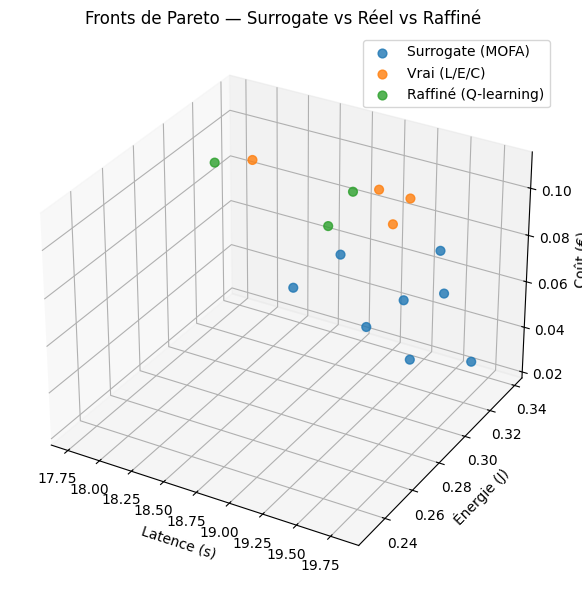

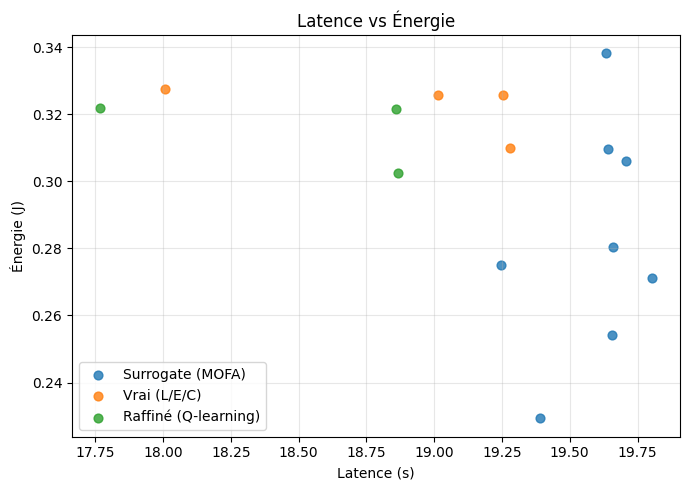

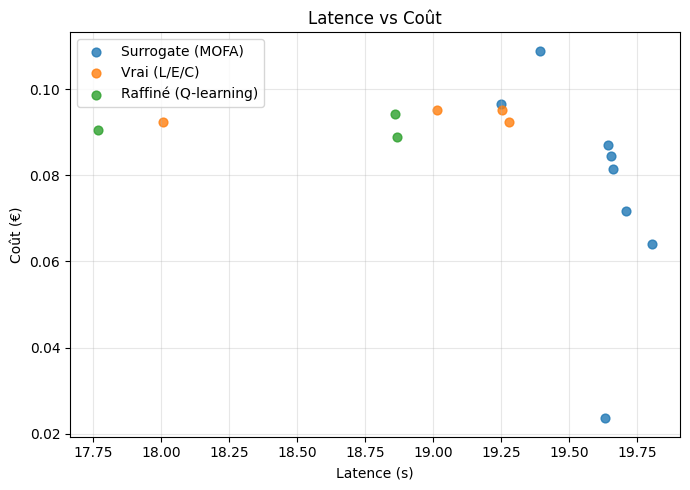

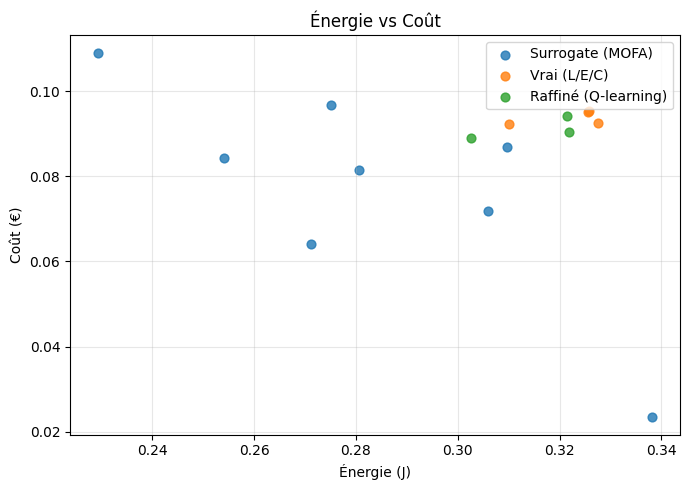

In [24]:
# ============================================================
#  ÉTAPE 6 — VISUALISATION DES FRONTS
#  (Surrogate vs Vrai vs Raffiné)
# ============================================================

def plot_pareto_3d(fronts, labels, title):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for F, lbl, col in zip(fronts, labels, colors):
        ax.scatter(F[:,0], F[:,1], F[:,2], c=col, alpha=0.8, s=40, label=lbl)
    ax.set_xlabel("Latence (s)")
    ax.set_ylabel("Énergie (J)")
    ax.set_zlabel("Coût (€)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_pareto_2d(fronts, labels, ix, iy, xlabel, ylabel, title):
    plt.figure(figsize=(7,5))
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for F, lbl, col in zip(fronts, labels, colors):
        plt.scatter(F[:,ix], F[:,iy], c=col, alpha=0.8, s=40, label=lbl)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


fronts = [front_F_surr, archive_F, front_F_final]
labels = ["Surrogate (MOFA)", "Vrai (L/E/C)", "Raffiné (Q-learning)"]

# 3D
plot_pareto_3d(fronts, labels, "Fronts de Pareto — Surrogate vs Réel vs Raffiné")

# 2D projections
plot_pareto_2d(fronts, labels, 0, 1, "Latence (s)", "Énergie (J)",
               "Latence vs Énergie")
plot_pareto_2d(fronts, labels, 0, 2, "Latence (s)", "Coût (€)",
               "Latence vs Coût")
plot_pareto_2d(fronts, labels, 1, 2, "Énergie (J)", "Coût (€)",
               "Énergie vs Coût")
